# Runtime comparison: LES-H (Ours) vs FZ vs DES/DES-H (Ours)/LLES

In [ ]:
import os
import torch
import warnings
from numpy.random import default_rng
import numpy as np
import sys
import math
import importlib
import seaborn as sns
import matplotlib.pyplot as plt
# import logging

from argparse import Namespace
from joblib import Parallel, delayed
from tqdm.notebook import tqdm
from scipy.stats import t, norm
from sklearn.model_selection import train_test_split
from utl import (generate_dgp_data_with_test_sn, gen_data_betamixing, QtES_LP, generate_dgp_data_with_test,
generate_dgp_data_with_test1,Qt_Linear)

from quantes.nonlinear import FNN, LocPoly
from quantes.linear import joint
print(torch.cuda.is_available())
warnings.filterwarnings('ignore', category=RuntimeWarning)


False


In [ ]:
args = Namespace(
    tau=0.1,
    dof=2.25,
    scale_norm=1,
    scale_t=1/3,
    n_train = np.array([2**11 + i * 1024 for i in range(11)]),
    h=64,
    batch_size=128,
    val_pct=0.3,
    activation='relu',
    optimizer='adam',
    lr=0.0001,
    max_epochs=400,
    patience=30,
    seed=2024,
    device = 'cpu'
)

In [ ]:
params = {'batch_size' : args.batch_size, 
          'val_pct' : args.val_pct, 
          'width': [args.h, 2*args.h, 2*args.h, args.h],
          'activation' : args.activation, 
          'optimizer' : args.optimizer, 
          'lr' : args.lr,
          'n_epochs' : args.max_epochs,
          'early_stopping_patience' : args.patience}



In [5]:
import time
import math
import numpy as np
from quantes.linear import joint
from utl import Qt_Linear


def time_linear_fz(seed, n, d=30, dof=4, error_type='normal', err_scale=None,
                    intercept=True, standardize=True, val_pct=None):
    """在同一份 sn-DGP 样本上，各计时一次 LES-H(Ours, 截断) 与 FZ 的点估计拟合。
    只计时“拟合”本身（截断阈值选取 + fit + twostep / fz），不含数据生成、不含推断(CI)。
    返回 (t_ours, t_fz)，单位秒。"""
    scale_norm = 1
    scale_t = 1/np.sqrt(2)
    if err_scale is None:
        err_scale = scale_norm if error_type == 'normal' else scale_t
    if val_pct is None:
        val_pct = args.val_pct
    n_lag = int(d / 2)
    n_indep = d - n_lag
    X_all, Y_all, Qt, ES, _, beta_true, *_ = generate_dgp_data_with_test_sn(
        n, 1024, d, tau=args.tau, err_dist=error_type, df=dof,
        rho_x=0.8, rho_e=0.9, n_lag=n_lag, n_indep=n_indep,
        err_scale=err_scale, seed=seed)
    X = X_all[:n, :]
    Y = Y_all[:n]

    # ---------- Ours (LES-H, 截断): 截断阈值选取 + fit + twostep(Huber) ----------
    t0 = time.perf_counter()
    n_val = math.floor(val_pct * n)
    train_idx = list(range(0, n - n_val))
    val_idx = list(range(n - n_val, n))
    q75 = np.quantile(np.abs(X[:, intercept:]), 0.75, axis=0)
    mx = np.max(np.abs(X[:, intercept:]), axis=0)
    vsigma = np.linspace(np.max(q75), np.max(mx), 10)
    bv = Qt_Linear(X[train_idx], Y[train_idx], X[val_idx], Y[val_idx],
                   args.tau, vsigma, standardize=standardize,
                   intercept=intercept, plot=False)
    X1 = X.copy()
    X1[:, intercept:] = np.clip(X1[:, intercept:], -bv['bvsigma_q'], bv['bvsigma_q'])
    lm = joint(X1, Y, intercept=intercept)
    qrfit = lm.fit(tau=args.tau, kernel='Laplacian', standardize=standardize)
    # robust = 0.25 * np.mean((np.minimum(qrfit['res'], 0) / args.tau) ** 4) ** 0.25 \
    #     * (n / d / (np.log(n) ** 2)) ** (1 / 6)
    _ = lm.twostep(tau=args.tau, loss='Huber', new = True, standardize=standardize,
                   ci=False)
    t_ours = time.perf_counter() - t0

    # ---------- FZ ----------
    t0 = time.perf_counter()
    lm1 = joint(X.copy(), Y, intercept=intercept)
    _ = lm1.fz(tau=args.tau, standardize=standardize, refit=False)
    t_fz = time.perf_counter() - t0

    return t_ours, t_fz


def safe_time_linear_fz(seed, **kw):
    try:
        return time_linear_fz(seed, **kw)
    except Exception as e:
        print('Error in time_linear_fz:', e)
        return np.nan, np.nan

In [ ]:
from utl import gen_data_betamixing, gen_data_iid

bw_q = np.linspace(0.1, 0.9, 20)
bw_e = np.linspace(0.25, 1.5, 20)


def time_nn_variants(seed, n, error_type='normal', exponent=.2, type="EXPAR_v1", v=0.5, dgp='beta'):
    """
    On the same sample from a nonlinear DGP, time the execution of DES (quantile network FNN.qt + non-robust LS network FNN.ls(robust=False))  and DES-H (same quantile network + Huber robust LS network FNN.ls(robust=True, c=huber_param)).  Both share the fitting time of the first-step quantile network, and the second step of each is timed separately. Data generation time is excluded.  
    Return (t_des, t_des_h) in seconds.
    """
    device = args.device
    err_scale = args.scale_norm if error_type == 'normal' else args.scale_t
    if dgp == 'beta':
        X_all, Y_all, Qt, ES = gen_data_betamixing(
            n=n, type=type, err_dist=error_type, df=args.dof,
            err_scale=err_scale, random_state=seed, v=v)
    else:
        X_all, Y_all, Qt, ES = gen_data_iid(
            n=n, err_dist=error_type, df=args.dof,
            err_scale=err_scale, random_state=seed)
    X = X_all[:n, :]
    Y = Y_all[:n]

    t0 = time.perf_counter()
    torch.manual_seed(0)
    nn1 = FNN(X, Y)
    nn1.qt(tau=args.tau, options=params, device=device)
    fit_q = nn1.predict(X)
    t_qt = time.perf_counter() - t0
    Z = np.minimum(Y - fit_q, 0) / args.tau
    huber_param = 0.25 * np.std(Z) * (n / np.log(n)) ** exponent

    t0 = time.perf_counter()
    torch.manual_seed(1)
    nn_des = FNN(X, Z + fit_q)
    nn_des.ls(options=params, robust=False, device=device)
    t_ls_plain = time.perf_counter() - t0

    t0 = time.perf_counter()
    torch.manual_seed(1)
    nn_desh = FNN(X, Z + fit_q)
    nn_desh.ls(options=params, robust=True, c=huber_param, device=device)
    t_ls_huber = time.perf_counter() - t0

    return t_qt + t_ls_plain, t_qt + t_ls_huber


def safe_time_nn_variants(seed, **kw):
    try:
        return time_nn_variants(seed, **kw)
    except Exception as e:
        print('Error in time_nn_variants:', e)
        return np.nan, np.nan


def time_locallinear(seed, n, error_type='normal', type="EXPAR_v1", v=0.5, dgp='beta'):
    """On the same sample of nonlinear DGP, time the LLES and LES-H method (ll_fix from dep.ipynb:  
    QtES_LP validation set bandwidth selection + LocPoly.qt_predict + LocPoly.ls_predict).  
    Difference from ll_fix: the query points for ls_predict are taken from the training set X (instead of a fixed test set of 1024), so that the time increases with n, aligning with the "fitting time increases with n" metric of Ours/DES.  
    Excluding data generation. Return t_ll, in seconds."""
    err_scale = args.scale_norm if error_type == 'normal' else args.scale_t
    if dgp == 'beta':
        X_all, Y_all, Qt, ES = gen_data_betamixing(
            n=n, type=type, err_dist=error_type, df=args.dof,
            err_scale=err_scale, random_state=seed, v=v)
    else:
        X_all, Y_all, Qt, ES = gen_data_iid(
            n=n, err_dist=error_type, df=args.dof,
            err_scale=err_scale, random_state=seed)
    X = X_all[:n, :]
    Y = Y_all[:n]

    n_val = int(params['val_pct'] * n)
    train_idx = list(range(0, n - n_val))
    val_idx = list(range(n - n_val, n))

    t0 = time.perf_counter()
    tuning = QtES_LP(X[train_idx], Y[train_idx], X[val_idx], Y[val_idx], args.tau,
                     norm.pdf, bw_q, 1, norm.pdf, bw_e, 1)
    lp = LocPoly(X, Y, kernel=norm.pdf)
    fit_q = lp.qt_predict(X, tau=args.tau, bw=tuning['bw_q'], degree=1)
    surrogate_Y = np.minimum(Y - fit_q, 0) / args.tau + fit_q
    lp_e = LocPoly(X, surrogate_Y, kernel=norm.pdf)
    _ = lp_e.ls_predict(X, bw=tuning['bw_e'], degree=1)
    t_ll = time.perf_counter() - t0
    return t_ll


def safe_time_locallinear(seed, **kw):
    try:
        return time_locallinear(seed, **kw)
    except Exception as e:
        print('Error in time_locallinear:', e)
        return np.nan

In [ ]:
from tqdm.notebook import tqdm


def run_runtime_comparison(n_grid=None, reps=5, d=30, dof=3.5, error_type='normal',
                            intercept=True, standardize=True,
                            nn_type="EXPAR_v1", nn_dgp='beta', nn_v=0.5, nn_exponent=.2):
    """Execute sequentially (without using joblib.Parallel) to obtain clean wall-clock time unaffected by thread contention;  
    Each sample size n is independently repeated reps times (using different seeds for each) to calculate the mean/standard deviation.  
    The linear part (Ours/FZ) uses sn(dependent) DGP; the NN part (DES/DES-H/LLES) uses a nonlinear DGP.  
    Return a dict: {'n_grid':…, 'ours':(mean,std), 'fz':(mean,std),  
                'des':(mean,std), 'des_h':(mean,std), 'll':(mean,std)}"""
    if n_grid is None:
        n_grid = np.array([2 ** 11 + i * 1024 for i in range(11)])
    n_grid = np.asarray(n_grid)
    t_ours = np.zeros((len(n_grid), reps))
    t_fz = np.zeros((len(n_grid), reps))
    t_des = np.zeros((len(n_grid), reps))
    t_desh = np.zeros((len(n_grid), reps))
    t_ll = np.zeros((len(n_grid), reps))
    for i, n in enumerate(tqdm(n_grid)):
        n = int(n)
        for r in range(reps):
            seed = r * 10007 + n
            t_ours[i, r], t_fz[i, r] = time_linear_fz(
                seed, n=n, d=d, dof=dof, error_type=error_type,
                intercept=intercept, standardize=standardize)
            print('fz done')
            t_des[i, r], t_desh[i, r] = time_nn_variants(
                seed, n=n, error_type=error_type, exponent=nn_exponent,
                type=nn_type, v=nn_v, dgp=nn_dgp)
            print('nn done')
            t_ll[i, r] = time_locallinear(
                seed, n=n, error_type=error_type, type=nn_type, v=nn_v, dgp=nn_dgp)
            print('ll done')
    return {
        'n_grid': n_grid,
        'ours': (np.nanmean(t_ours, axis=1), np.nanstd(t_ours, axis=1)),
        'fz': (np.nanmean(t_fz, axis=1), np.nanstd(t_fz, axis=1)),
        'des': (np.nanmean(t_des, axis=1), np.nanstd(t_des, axis=1)),
        'des_h': (np.nanmean(t_desh, axis=1), np.nanstd(t_desh, axis=1)),
        'll': (np.nanmean(t_ll, axis=1), np.nanstd(t_ll, axis=1)),
    }

In [ ]:
import matplotlib.pyplot as plt


def plot_linear_runtime(res, title=None, fname=None, logy=True):
    """Linear runtime chart: LES-H (Ours) vs FZ."""
    n_grid = res['n_grid']
    plt.style.use('seaborn-v0_8-darkgrid')
    fig, ax = plt.subplots(figsize=(6.4, 4.2))
    for key, label, mk, col in [('ours', 'LES-H', 'o', 'C0'),
                                 ('fz', 'FZ', 's', 'C1')]:
        mean, std = res[key]
        # ax.errorbar(n_grid, mean, yerr=std, marker=mk, markersize=6,
        #             linewidth=1.3, capsize=3, label=label, color=col)
        ax.plot(
            n_grid,
            mean,
            marker=mk,
            markersize=6,
            linewidth=1.3,
            label=label,
            color=col
        )
    if logy:
        ax.set_yscale('log')
    ax.set_xlabel(r'Sample size', fontsize=10)
    ax.set_ylabel('Runtime (s)', fontsize=10)
    ax.tick_params(labelsize=9)
    ax.legend(fontsize=9)
    if title:
        ax.set_title(title, fontsize=11)
    fig.tight_layout()
    if fname:
        fig.savefig(fname, bbox_inches='tight', format="pdf")
    plt.show()
    return fig


def plot_nn_runtime(res, title=None, fname=None, logy=True):
    """Nonlinear runtime comparison chart: DES vs DES-H vs LLES."""
    n_grid = res['n_grid']
    plt.style.use('seaborn-v0_8-darkgrid')
    fig, ax = plt.subplots(figsize=(6.4, 4.2))
    # for key, label, mk, col in [('des', 'DES', 'o', 'C0'),
    #                              ('des_h', 'DES-H', 's', 'C1'),
    #                              ('ll', 'LLES', '^', 'C2')]:
    for key, label, mk, col in [('ll', 'LLES', 'o', 'C0'),
                                ('des', 'DES', 's', 'C1'),
                                 ('des_h', 'DES-H', '^', 'C2')
                                 ]:
        mean, std = res[key]
        # ax.errorbar(n_grid, mean, yerr=std, marker=mk, markersize=6,
        #             linewidth=1.3, capsize=3, label=label, color=col)
        ax.plot(
            n_grid,
            mean,
            marker=mk,
            markersize=6,
            linewidth=1.3,
            label=label,
            color=col
        )
    if logy:
        ax.set_yscale('log')
    ax.set_xlabel(r'Sample size', fontsize=10)
    ax.set_ylabel('Runtime (s)', fontsize=10)
    ax.tick_params(labelsize=9)
    ax.legend(fontsize=9)
    if title:
        ax.set_title(title, fontsize=11)
    fig.tight_layout()
    if fname:
        fig.savefig(fname, bbox_inches='tight', format="pdf")
    plt.show()
    return fig

In [ ]:
n_grid = np.array([4000 + i * 1000 for i in range(9)])   # 可自行扩展

res_normal = run_runtime_comparison(
    n_grid=n_grid, reps=50, d=30, dof=4, error_type='normal',
    intercept=True, standardize=True, nn_type="EXPAR_v1", nn_dgp='beta')
fig_lin_n = plot_linear_runtime(
    res_normal, title=r'Linear runtime ($\varepsilon_t\sim\mathcal{N}$)',
    fname='runtime_linear_normal.pdf')
fig_nn_n = plot_nn_runtime(
    res_normal, title=r'NN runtime ($\varepsilon_t\sim\mathcal{N}$)',
    fname='runtime_nn_normal.pdf')

res_t = run_runtime_comparison(
    n_grid=n_grid, reps=50, d=30, dof=4, error_type='t',
    intercept=True, standardize=True, nn_type="EXPAR_v1", nn_dgp='beta')
fig_lin_t = plot_linear_runtime(
    res_t, title=r'Linear runtime ($\varepsilon_t\sim t$)',
    fname='runtime_linear_t.pdf')
fig_nn_t = plot_nn_runtime(
    res_t, title=r'NN runtime ($\varepsilon_t\sim t$)',
    fname='runtime_nn_t.pdf')

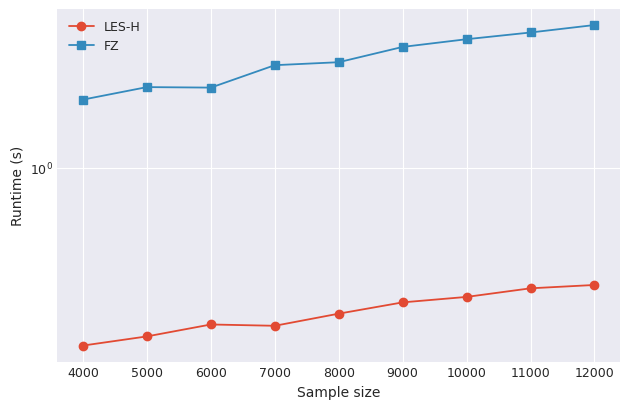

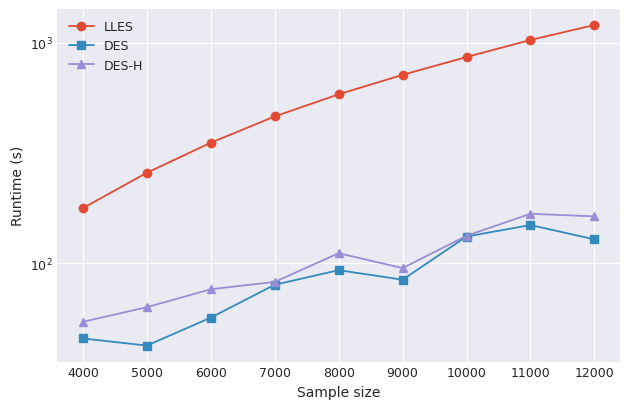

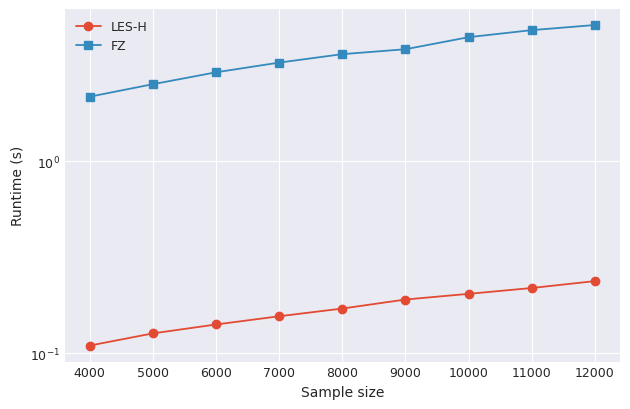

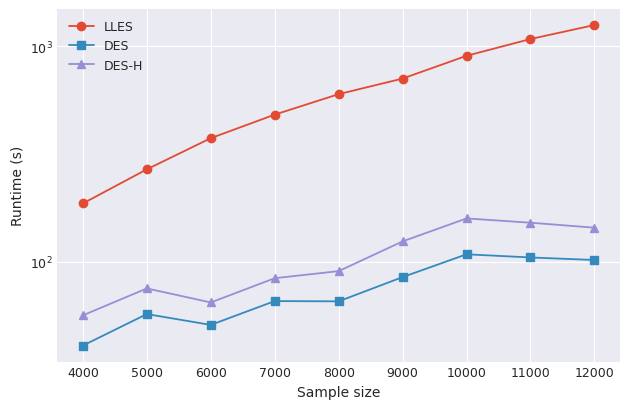

In [ ]:
os.makedirs("./res_runtime/", exist_ok=True)
np.savez('./res_runtime/res_normal.npz', result=res_normal)
np.savez('./res_runtime/res_t.npz', result=res_t)
fig_lin_n = plot_linear_runtime(
    res_normal,
    fname='runtime_linear_normal.pdf')
fig_nn_n = plot_nn_runtime(
    res_normal,
    fname='runtime_nn_normal.pdf')
fig_lin_t = plot_linear_runtime(
    res_t,
    fname='runtime_linear_t.pdf')
fig_nn_t = plot_nn_runtime(
    res_t,
    fname='runtime_nn_t.pdf')